In [28]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    '/kaggle/input/datasets/dhruvil121/flood-prediction-dataset/flood.csv'
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (50000, 21)


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [29]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/dhruvil121/flood-prediction-dataset/flood.csv


In [30]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

In [31]:
print("Missing Values:")
print(df.isnull().sum().sum())

Missing Values:
0


In [32]:
df['FloodRisk'] = (
    df['FloodProbability'] >= 0.5
).astype(int)

print(df['FloodRisk'].value_counts())

FloodRisk
1    25513
0    24487
Name: count, dtype: int64


In [33]:
from sklearn.model_selection import train_test_split

X = df.drop(
    columns=['FloodProbability', 'FloodRisk']
)

y = df['FloodRisk']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (40000, 20)
Testing Shape: (10000, 20)


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest Training Complete")

Random Forest Training Complete


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9081
Precision: 0.9168991630131527
Recall   : 0.9016264942190868
F1 Score : 0.9091986957810493


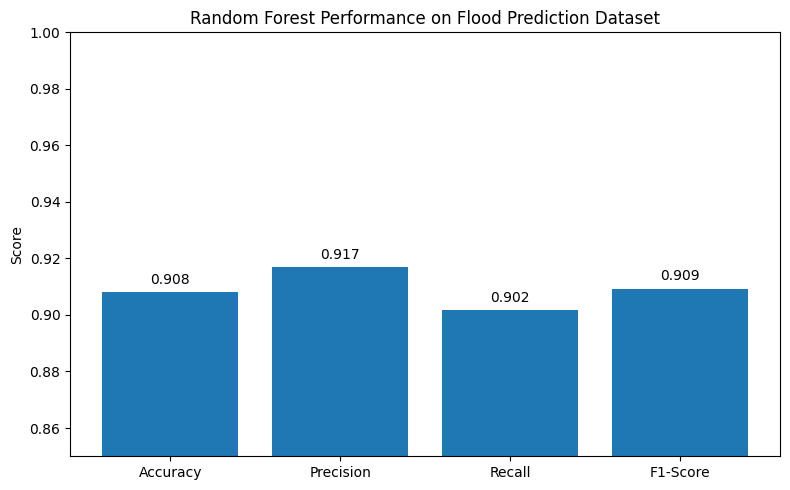

In [36]:
import matplotlib.pyplot as plt

metrics = {
    'Accuracy': 0.9081,
    'Precision': 0.9169,
    'Recall': 0.9016,
    'F1-Score': 0.9092
}

plt.figure(figsize=(8,5))

bars = plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0.85,1.0)

plt.ylabel('Score')
plt.title('Random Forest Performance on Flood Prediction Dataset')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f'{height:.3f}',
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    'RQ1_Performance_Metrics.pdf',
    bbox_inches='tight'
)

plt.show()

In [37]:
import pandas as pd

results = pd.DataFrame({
    'Metric':[
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    'Value':[
        0.9081,
        0.9169,
        0.9016,
        0.9092
    ]
})

results.to_csv(
    'RQ1_Performance_Table.csv',
    index=False
)

results

,Metric,Value
0,Accuracy,0.9081
1,Precision,0.9169
2,Recall,0.9016
3,F1 Score,0.9092


In [38]:
y_prob = rf.predict_proba(X_test)

confidence_scores = y_prob.max(axis=1)

print(confidence_scores[:10])

[0.835 0.78  0.825 0.73  0.74  0.515 0.675 0.675 0.64  0.68 ]


In [39]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

thresholds = [0.50, 0.60, 0.70, 0.80, 0.90]

results = []

for t in thresholds:

    review_mask = confidence_scores < t

    hitl_predictions = y_pred.copy()

    # Simulated human review
    hitl_predictions[review_mask] = y_test.iloc[
        np.where(review_mask)[0]
    ]

    accuracy = accuracy_score(
        y_test,
        hitl_predictions
    )

    reviewed_cases = review_mask.sum()

    results.append([
        t,
        reviewed_cases,
        accuracy
    ])

rq2_table = pd.DataFrame(
    results,
    columns=[
        'Threshold',
        'Cases_Reviewed',
        'Accuracy'
    ]
)

rq2_table

,Threshold,Cases_Reviewed,Accuracy
0,0.5,0,0.9081
1,0.6,3009,0.9906
2,0.7,5854,0.9999
3,0.8,8011,1.0000
4,0.9,9404,1.0000


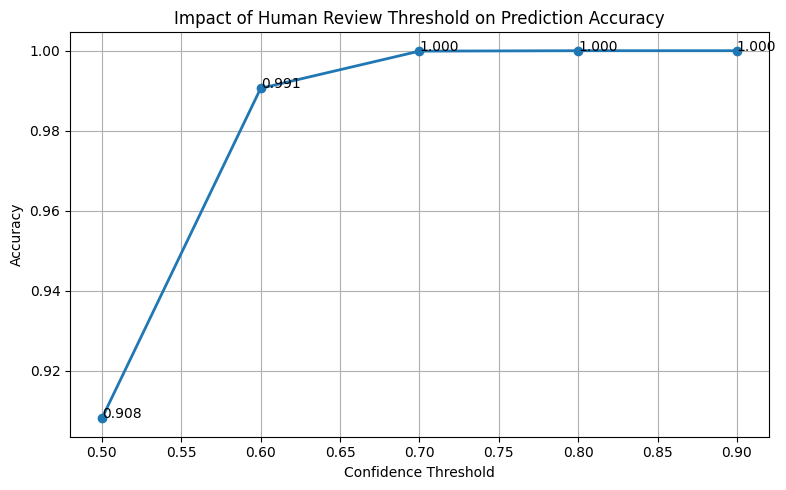

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    rq2_table['Threshold'],
    rq2_table['Accuracy'],
    marker='o',
    linewidth=2
)

plt.xlabel('Confidence Threshold')
plt.ylabel('Accuracy')
plt.title('Impact of Human Review Threshold on Prediction Accuracy')

for i,row in rq2_table.iterrows():
    plt.text(
        row['Threshold'],
        row['Accuracy'],
        f"{row['Accuracy']:.3f}"
    )

plt.grid(True)

plt.tight_layout()

plt.savefig(
    'RQ2_Threshold_Analysis.pdf',
    bbox_inches='tight'
)

plt.show()

In [41]:
rq2_table.to_csv(
    'RQ2_Threshold_Table.csv',
    index=False
)

rq2_table


,Threshold,Cases_Reviewed,Accuracy
0,0.5,0,0.9081
1,0.6,3009,0.9906
2,0.7,5854,0.9999
3,0.8,8011,1.0000
4,0.9,9404,1.0000


In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[4480  417]
 [ 502 4601]]


In [43]:
TN, FP, FN, TP = cm.ravel()

print("True Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives :", TP)

True Negatives : 4480
False Positives: 417
False Negatives: 502
True Positives : 4601


In [44]:
rq3_table = pd.DataFrame({
    'Error Type':[
        'False Positives',
        'False Negatives'
    ],
    'Count':[
        FP,
        FN
    ]
})

rq3_table

,Error Type,Count
0,False Positives,417
1,False Negatives,502


In [45]:
rq3_table.to_csv(
    'RQ3_Error_Analysis_Table.csv',
    index=False
)

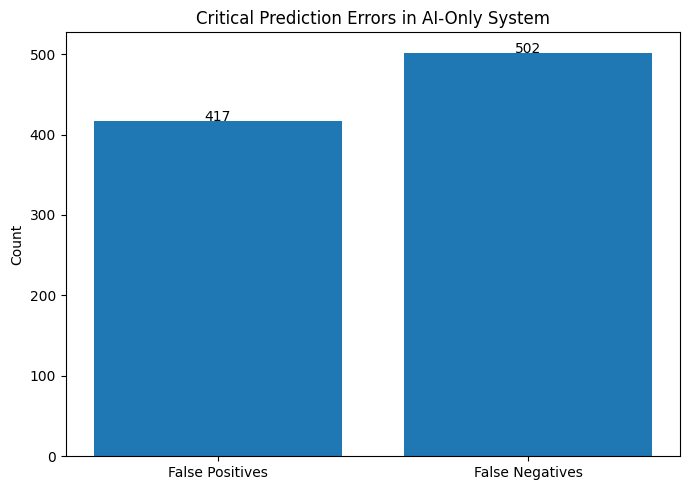

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    rq3_table['Error Type'],
    rq3_table['Count']
)

plt.ylabel('Count')
plt.title('Critical Prediction Errors in AI-Only System')

for i, v in enumerate(rq3_table['Count']):
    plt.text(i, v, str(v), ha='center')

plt.tight_layout()

plt.savefig(
    'RQ3_Error_Analysis.pdf',
    bbox_inches='tight'
)

plt.show()

In [47]:
!pip install shap -q

In [48]:
import shap

In [49]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(10)

,Feature,Importance
14,Watersheds,0.051827
10,IneffectiveDisasterPreparedness,0.051393
7,Siltation,0.051038
6,DamsQuality,0.050850
1,TopographyDrainage,0.050595
5,ClimateChange,0.050351
0,MonsoonIntensity,0.050326
3,Deforestation,0.050308
19,PoliticalFactors,0.050092
15,DeterioratingInfrastructure,0.049978


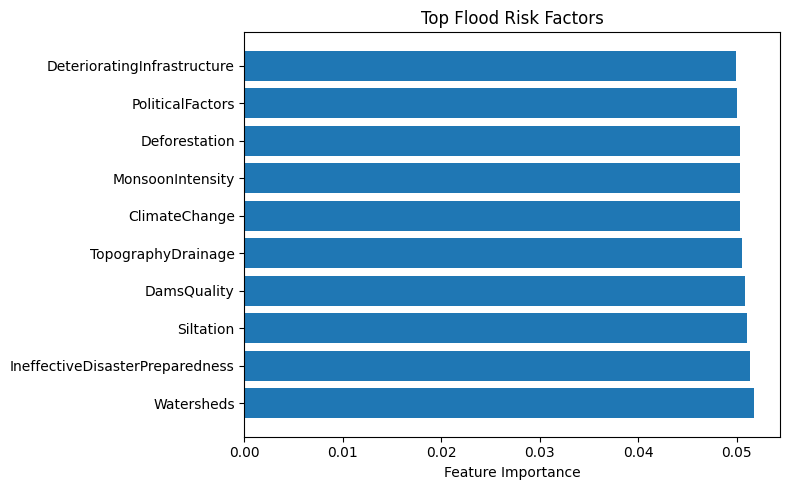

In [50]:
import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title('Top Flood Risk Factors')

plt.xlabel('Feature Importance')

plt.tight_layout()

plt.savefig(
    'RQ4_Feature_Importance.pdf',
    bbox_inches='tight'
)

plt.show()

In [51]:
importance_df.head(10).to_csv(
    'RQ4_Feature_Importance_Table.csv',
    index=False
)

importance_df.head(10)

,Feature,Importance
14,Watersheds,0.051827
10,IneffectiveDisasterPreparedness,0.051393
7,Siltation,0.051038
6,DamsQuality,0.050850
1,TopographyDrainage,0.050595
5,ClimateChange,0.050351
0,MonsoonIntensity,0.050326
3,Deforestation,0.050308
19,PoliticalFactors,0.050092
15,DeterioratingInfrastructure,0.049978


In [52]:
rq5_table = rq2_table.copy()

rq5_table.columns = [
    'Threshold',
    'Cases_Reviewed',
    'Accuracy'
]

rq5_table

,Threshold,Cases_Reviewed,Accuracy
0,0.5,0,0.9081
1,0.6,3009,0.9906
2,0.7,5854,0.9999
3,0.8,8011,1.0000
4,0.9,9404,1.0000


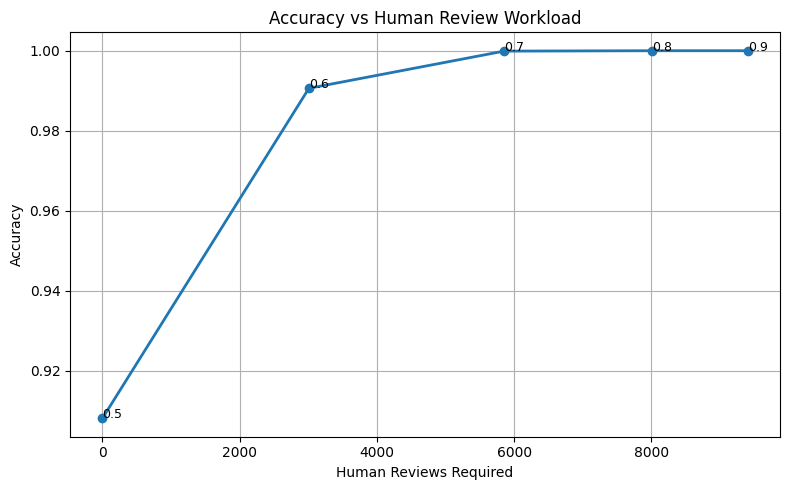

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    rq5_table['Cases_Reviewed'],
    rq5_table['Accuracy'],
    marker='o',
    linewidth=2
)

for _, row in rq5_table.iterrows():
    plt.text(
        row['Cases_Reviewed'],
        row['Accuracy'],
        f"{row['Threshold']}",
        fontsize=9
    )

plt.xlabel("Human Reviews Required")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Human Review Workload")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    'RQ5_Accuracy_Workload_Tradeoff.pdf',
    bbox_inches='tight'
)

plt.show()

In [54]:
rq5_table.to_csv(
    'RQ5_Tradeoff_Table.csv',
    index=False
)

rq5_table

,Threshold,Cases_Reviewed,Accuracy
0,0.5,0,0.9081
1,0.6,3009,0.9906
2,0.7,5854,0.9999
3,0.8,8011,1.0000
4,0.9,9404,1.0000
